# Matched PCA–ICA Pair Figures

This notebook builds three figure styles for the matched PCA–ICA comparison analysis:

1. **2D matched-pair map**  
   - x = absolute spatial correlation  
   - y = predictive asymmetry = PCA L2 AUC − ICA L2 AUC  
   - optional labels for selected pairs  
   - optional point color by subject-level agreement score

2. **Matched-pair summary panel**  
   - three groups: shared-signal, PCA-dominant, ICA-dominant  
   - dumbbell-style comparison of PCA vs ICA L2 AUC

3. **Heatmap of pair metrics**  
   - rows = matched pairs  
   - columns = spatial and predictive/agreement metrics

The notebook is designed to work with either:
- a CSV exported from your matched-pair analysis, or
- a small manually entered table.

Update the configuration paths first.


In [14]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Configuration

Set `USE_CSV = True` if you want to load your full matched-pair table from disk.  
Otherwise set `USE_CSV = False` and use the manual table below.


In [15]:
# ---------- CONFIG ----------
USE_CSV = False

# Option A: load a CSV exported from your previous notebook
CSV_PATH = Path("matched_component_subject_level_interpretation_table.csv")

# Folder to save figures
OUTDIR = Path("./matched_pair_figures")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Whether to label all points in the scatter or only selected ones
LABEL_ALL_POINTS = False

# If not labeling all points, these pairs will be labeled if present
SELECTED_LABELS = [
    "PC11-IC12", "PC09-IC16", "PC02-IC04",
    "PC07-IC03", "PC10-IC01", "PC05-IC15",
    "PC01-IC08", "PC08-IC19", "PC13-IC02",
]

# Thresholds used for automatic interpretation groups
SHARED_MAX_AUC_GAP = 0.12
DOMINANT_MIN_AUC_GAP = 0.15
SHARED_MIN_SPATIAL_R = 0.20


## 2. Load matched-pair table

### Required columns
The notebook will work best if your table contains these columns:

- `pca_component`
- `ica_component`
- `abs_spatial_r`
- `dice_zthr2` or `dice`
- `pca_auc_ln` or `PCA_Ln_AUC`
- `ica_auc_ln` or `ICA_Ln_AUC`

### Optional helpful columns
- `overall_subject_agreement_score`
- `delta_effect_profile_corr`
- `ln_effect_profile_corr`
- `mean_feature_subject_corr_ln`

If your column names are different, edit the rename map below.


In [16]:
from pathlib import Path
import pandas as pd
import numpy as np

USE_CSV = True
CSV_PATH = Path("/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/matched_pair_figures/matched_pair_summary_for_figures.csv")  # <- change to your real file

def load_matched_pairs(csv_path: Path) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(
            f"CSV not found: {csv_path.resolve()}\n"
            "Please export your real matched-pair table from the analysis notebook first."
        )

    df = pd.read_csv(csv_path)

    rename_map = {
        "dice_zthr2": "dice",
        "pca_auc_ln": "PCA_Ln_AUC",
        "ica_auc_ln": "ICA_Ln_AUC",
        "overall_subject_agreement": "overall_subject_agreement_score",
        "agreement_score": "overall_subject_agreement_score",
    }
    rename_subset = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=rename_subset)

    required = ["pca_component", "ica_component", "abs_spatial_r", "PCA_Ln_AUC", "ICA_Ln_AUC"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing required columns: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    optional_cols = [
        "dice",
        "overall_subject_agreement_score",
        "delta_effect_profile_corr",
        "ln_effect_profile_corr",
        "mean_feature_subject_corr_ln",
    ]
    for col in optional_cols:
        if col not in df.columns:
            df[col] = np.nan

    df["pair"] = df["pca_component"].astype(str) + "–" + df["ica_component"].astype(str)
    df["auc_diff"] = df["PCA_Ln_AUC"] - df["ICA_Ln_AUC"]
    df["auc_mean"] = (df["PCA_Ln_AUC"] + df["ICA_Ln_AUC"]) / 2.0

    return df

pairs_df = load_matched_pairs(CSV_PATH)
pairs_df.head()

,pca_component,ica_component,pair,group,abs_spatial_r,dice,PCA_Ln_AUC,ICA_Ln_AUC,auc_diff,overall_subject_agreement_score,delta_effect_profile_corr,ln_effect_profile_corr,mean_feature_subject_corr_ln,auc_mean
0,PC08,IC19,PC08–IC19,ICA-dominant,0.210,NaN,0.388,0.618,-0.230,0.410,0.310,0.220,0.18,0.5030
1,PC01,IC08,PC01–IC08,ICA-dominant,0.376,NaN,0.358,0.703,-0.345,0.430,0.280,0.410,0.26,0.5305
2,PC07,IC03,PC07–IC03,PCA-dominant,0.058,NaN,0.788,0.261,0.527,0.344,0.120,0.050,0.10,0.5245
3,PC10,IC01,PC10–IC01,PCA-dominant,0.212,NaN,0.691,0.509,0.182,0.520,0.420,0.300,0.22,0.6000
4,PC09,IC16,PC09–IC16,mixed/unclear,0.291,NaN,0.703,0.576,0.127,0.697,0.994,0.803,0.42,0.6395


In [17]:
print("Rows:", len(pairs_df))
print("Columns:", list(pairs_df.columns))
pairs_df.sort_values("auc_diff", ascending=False)


Rows: 7
Columns: ['pca_component', 'ica_component', 'pair', 'group', 'abs_spatial_r', 'dice', 'PCA_Ln_AUC', 'ICA_Ln_AUC', 'auc_diff', 'overall_subject_agreement_score', 'delta_effect_profile_corr', 'ln_effect_profile_corr', 'mean_feature_subject_corr_ln', 'auc_mean']


,pca_component,ica_component,pair,group,abs_spatial_r,dice,PCA_Ln_AUC,ICA_Ln_AUC,auc_diff,overall_subject_agreement_score,delta_effect_profile_corr,ln_effect_profile_corr,mean_feature_subject_corr_ln,auc_mean
2,PC07,IC03,PC07–IC03,PCA-dominant,0.058,NaN,0.788,0.261,0.527,0.344,0.120,0.050,0.10,0.5245
3,PC10,IC01,PC10–IC01,PCA-dominant,0.212,NaN,0.691,0.509,0.182,0.520,0.420,0.300,0.22,0.6000
4,PC09,IC16,PC09–IC16,mixed/unclear,0.291,NaN,0.703,0.576,0.127,0.697,0.994,0.803,0.42,0.6395
5,PC11,IC12,PC11–IC12,shared-signal,0.234,NaN,0.776,0.679,0.097,0.776,0.971,0.981,0.48,0.7275
6,PC02,IC04,PC02–IC04,shared-signal,0.411,NaN,0.467,0.503,-0.036,0.610,0.536,0.500,0.35,0.4850
0,PC08,IC19,PC08–IC19,ICA-dominant,0.210,NaN,0.388,0.618,-0.230,0.410,0.310,0.220,0.18,0.5030
1,PC01,IC08,PC01–IC08,ICA-dominant,0.376,NaN,0.358,0.703,-0.345,0.430,0.280,0.410,0.26,0.5305


## 3. Add interpretation groups

These groups are useful for the summary panel and for color-coding figures.

### Automatic rule used here
- **shared-signal candidate**: moderate spatial similarity and small AUC gap
- **PCA-dominant pair**: PCA clearly stronger than ICA
- **ICA-dominant pair**: ICA clearly stronger than PCA
- otherwise: **mixed / unclear**

You can override the labels manually below if you want.


In [18]:
def auto_assign_group(row,
                      shared_max_auc_gap=SHARED_MAX_AUC_GAP,
                      dominant_min_auc_gap=DOMINANT_MIN_AUC_GAP,
                      shared_min_spatial_r=SHARED_MIN_SPATIAL_R):
    gap = row["auc_diff"]
    spatial = row["abs_spatial_r"]

    if abs(gap) <= shared_max_auc_gap and spatial >= shared_min_spatial_r:
        return "shared-signal"
    elif gap >= dominant_min_auc_gap:
        return "PCA-dominant"
    elif gap <= -dominant_min_auc_gap:
        return "ICA-dominant"
    else:
        return "mixed/unclear"

pairs_df["group_auto"] = pairs_df.apply(auto_assign_group, axis=1)

manual_group_overrides = {
    # "PC11-IC12": "shared-signal",
    # "PC09-IC16": "shared-signal",
    # "PC02-IC04": "shared-signal",
    # "PC07-IC03": "PCA-dominant",
    # "PC10-IC01": "PCA-dominant",
    # "PC05-IC15": "PCA-dominant",
    # "PC01-IC08": "ICA-dominant",
    # "PC08-IC19": "ICA-dominant",
    # "PC13-IC02": "ICA-dominant",
}
pairs_df["group"] = pairs_df["pair"].map(manual_group_overrides).fillna(pairs_df["group_auto"])

pairs_df[["pair", "abs_spatial_r", "PCA_Ln_AUC", "ICA_Ln_AUC", "auc_diff", "group"]].sort_values("group")


,pair,abs_spatial_r,PCA_Ln_AUC,ICA_Ln_AUC,auc_diff,group
0,PC08–IC19,0.210,0.388,0.618,-0.230,ICA-dominant
1,PC01–IC08,0.376,0.358,0.703,-0.345,ICA-dominant
2,PC07–IC03,0.058,0.788,0.261,0.527,PCA-dominant
3,PC10–IC01,0.212,0.691,0.509,0.182,PCA-dominant
4,PC09–IC16,0.291,0.703,0.576,0.127,mixed/unclear
5,PC11–IC12,0.234,0.776,0.679,0.097,shared-signal
6,PC02–IC04,0.411,0.467,0.503,-0.036,shared-signal


## 4. Figure 1 — 2D matched-pair map

This is the main figure:
- x = absolute spatial correlation
- y = PCA L2 AUC − ICA L2 AUC
- point color = subject-level agreement score if available, otherwise mean AUC


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import numpy as np

def plot_scatter_spatial_vs_asymmetry(
    df,
    outpath=None,
    label_all=False,
    selected_labels=None,
    figsize=(7.6, 5.8),
):
    data = df.copy()

    color_col = "overall_subject_agreement_score"
    if color_col not in data.columns or data[color_col].isna().all():
        color_col = "auc_mean"

    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        data["abs_spatial_r"],
        data["auc_diff"],
        c=data[color_col],
        s=110,
        alpha=0.95,
        edgecolors="black",
        linewidths=0.6,
    )

    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Absolute spatial correlation")
    ax.set_ylabel("Predictive asymmetry (PCA L2 AUC − ICA L2 AUC)")
    ax.set_title("Matched PCA–ICA pairs: spatial similarity vs predictive asymmetry")

    selected_labels = set(selected_labels or [])

    # label placement with small offsets
    for _, row in data.iterrows():
        should_label = label_all or (row["pair"] in selected_labels)
        if not should_label:
            continue

        x = row["abs_spatial_r"]
        y = row["auc_diff"]
        label = row["pair"]

        # simple directional offset rules
        if y >= 0.15:
            xytext = (8, 8)
            ha, va = "left", "bottom"
        elif y <= -0.15:
            xytext = (8, -8)
            ha, va = "left", "top"
        else:
            xytext = (10, 0)
            ha, va = "left", "center"

        ann = ax.annotate(
            label,
            xy=(x, y),
            xytext=xytext,
            textcoords="offset points",
            fontsize=8,
            ha=ha,
            va=va,
            arrowprops=dict(arrowstyle="-", lw=0.7, alpha=0.7),
        )
        ann.set_path_effects([
            patheffects.withStroke(linewidth=3, foreground="white")
        ])

    cbar = fig.colorbar(sc, ax=ax)
    if color_col == "overall_subject_agreement_score":
        cbar.set_label("Subject-level agreement score")
    else:
        cbar.set_label("Mean L2 AUC")

    # optional guide text
    ax.text(
        0.98, 0.97,
        "Above 0: PCA stronger\nBelow 0: ICA stronger",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="gray"),
    )

    plt.tight_layout()
    if outpath is not None:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

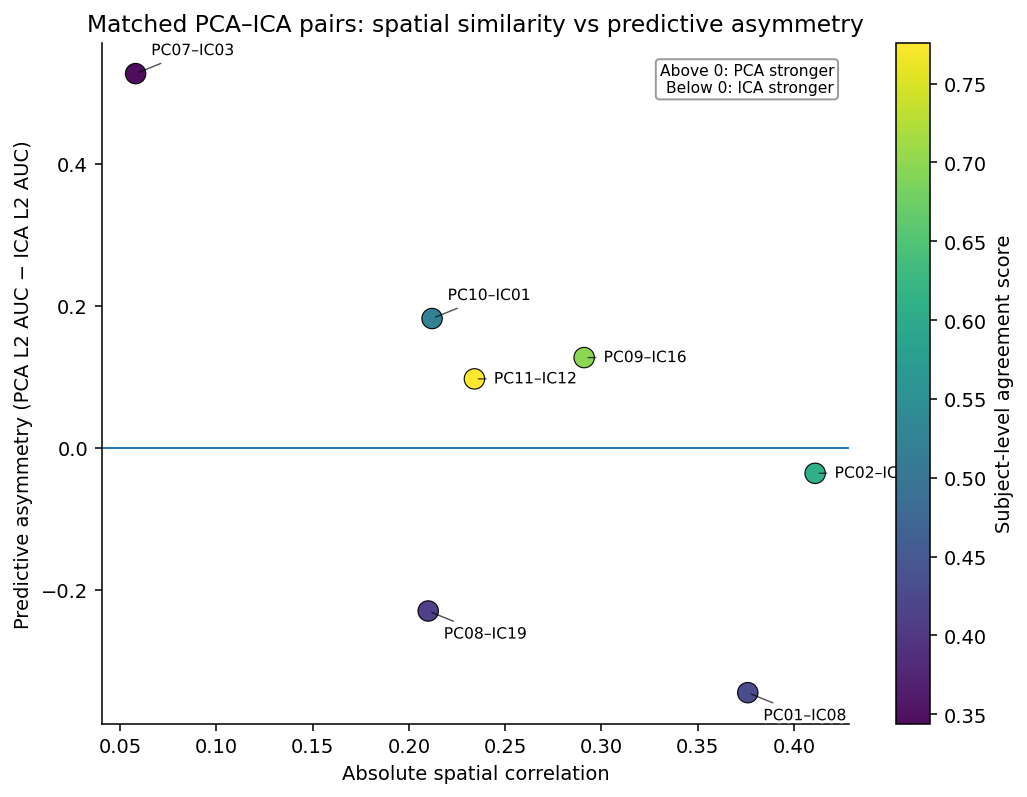

In [27]:
SELECTED_LABELS = [
    "PC11–IC12",
    "PC09–IC16",
    "PC02–IC04",
    "PC07–IC03",
    "PC10–IC01",
    "PC01–IC08",
    "PC08–IC19",
]

plot_scatter_spatial_vs_asymmetry(
    pairs_df,
    outpath=OUTDIR / "figure1_scatter_spatial_vs_asymmetry.png",
    label_all=False,
    selected_labels=SELECTED_LABELS,
)

## 5. Figure 2 — Matched-pair summary panel

This panel shows three groups:
- shared-signal
- PCA-dominant
- ICA-dominant

Within each group, each pair is shown as a dumbbell:
- one dot = PCA L2 AUC
- one square = ICA L2 AUC
- line connects the matched pair


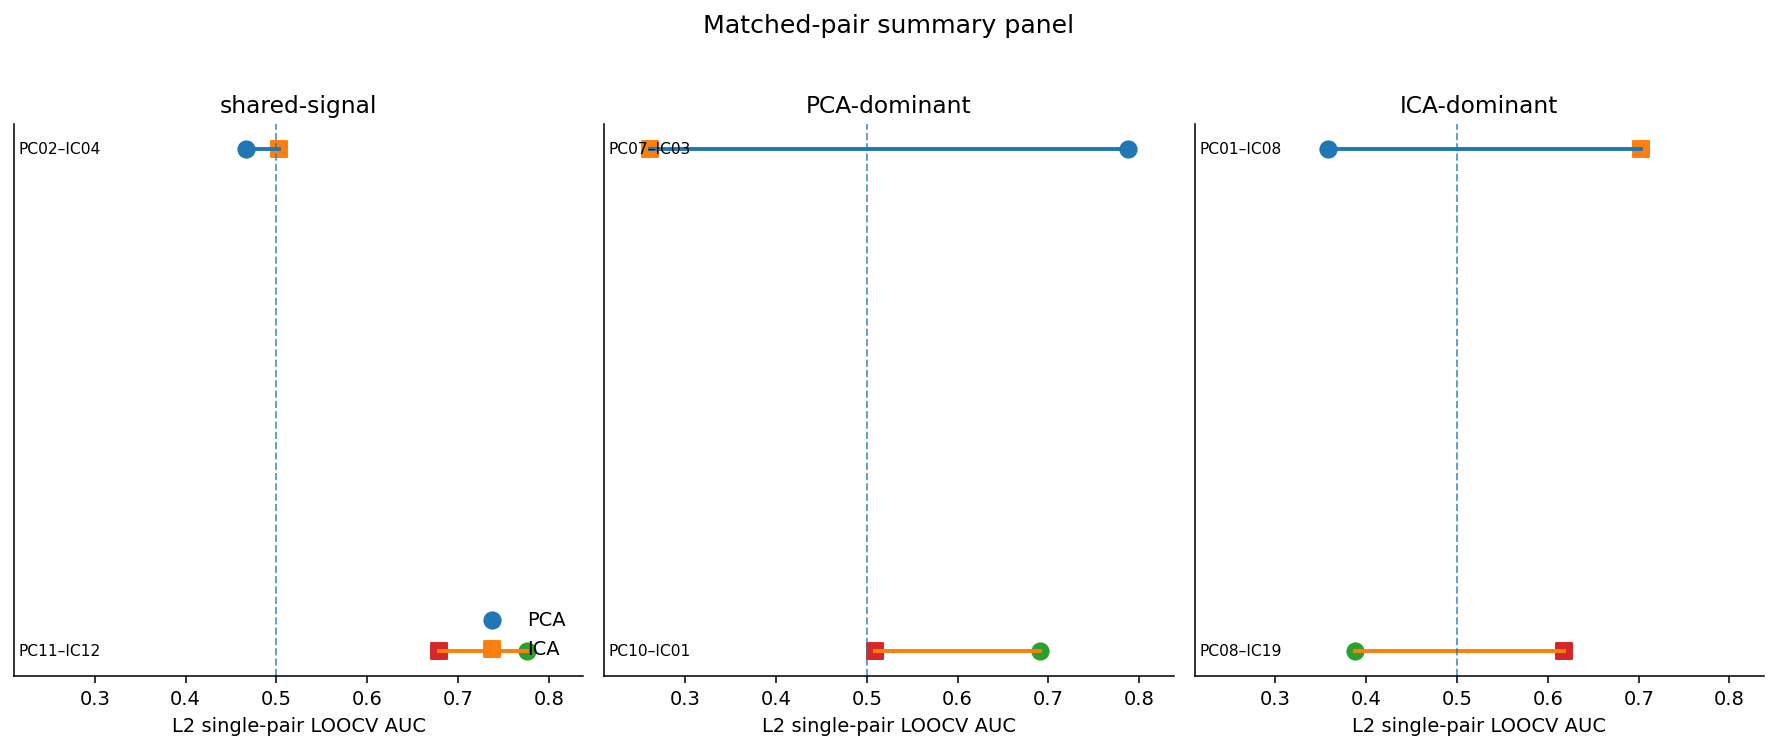

In [20]:
def plot_summary_panel_dumbbells(df, outpath=None):
    group_order = ["shared-signal", "PCA-dominant", "ICA-dominant"]
    panel_data = df[df["group"].isin(group_order)].copy()

    if panel_data.empty:
        raise ValueError("No rows available for the summary panel. Check group labels.")

    fig, axes = plt.subplots(1, 3, figsize=(12.8, 5.2), sharex=True, sharey=True)
    x_min = min(panel_data["PCA_Ln_AUC"].min(), panel_data["ICA_Ln_AUC"].min()) - 0.05
    x_max = max(panel_data["PCA_Ln_AUC"].max(), panel_data["ICA_Ln_AUC"].max()) + 0.05

    for ax, group in zip(axes, group_order):
        sub = panel_data[panel_data["group"] == group].copy()

        if sub.empty:
            ax.set_title(group)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(-1, 1)
            continue

        if group == "shared-signal":
            sub = sub.sort_values(["abs_spatial_r", "auc_mean"], ascending=[False, False])
        elif group == "PCA-dominant":
            sub = sub.sort_values("auc_diff", ascending=False)
        else:
            sub = sub.sort_values("auc_diff", ascending=True)

        y = np.arange(len(sub))[::-1]

        for yi, (_, row) in zip(y, sub.iterrows()):
            ax.plot([row["PCA_Ln_AUC"], row["ICA_Ln_AUC"]], [yi, yi], linewidth=2)
            ax.scatter(row["PCA_Ln_AUC"], yi, s=70, label="PCA" if yi == y[0] else "")
            ax.scatter(row["ICA_Ln_AUC"], yi, s=70, marker="s", label="ICA" if yi == y[0] else "")
            ax.text(x_min + 0.005, yi, row["pair"], va="center", fontsize=8)

        ax.set_title(group)
        ax.set_xlim(x_min, x_max)
        ax.set_yticks([])
        ax.set_xlabel("L2 single-pair LOOCV AUC")
        ax.axvline(0.5, linewidth=1, linestyle="--", alpha=0.7)

    axes[0].legend(loc="lower right", frameon=False)
    fig.suptitle("Matched-pair summary panel", y=1.02, fontsize=13)
    plt.tight_layout()

    if outpath is not None:
        plt.savefig(outpath, bbox_inches="tight")
    plt.show()


plot_summary_panel_dumbbells(
    pairs_df,
    outpath=OUTDIR / "figure2_summary_panel_dumbbells.png",
)


## 6. Figure 3 — Heatmap of pair metrics

This figure summarizes each matched pair across several dimensions:
- abs spatial correlation
- Dice
- PCA L2 AUC
- ICA L2 AUC
- AUC difference
- subject-level agreement
- effect-profile agreement

Rows are sorted by interpretation group and then by AUC difference.


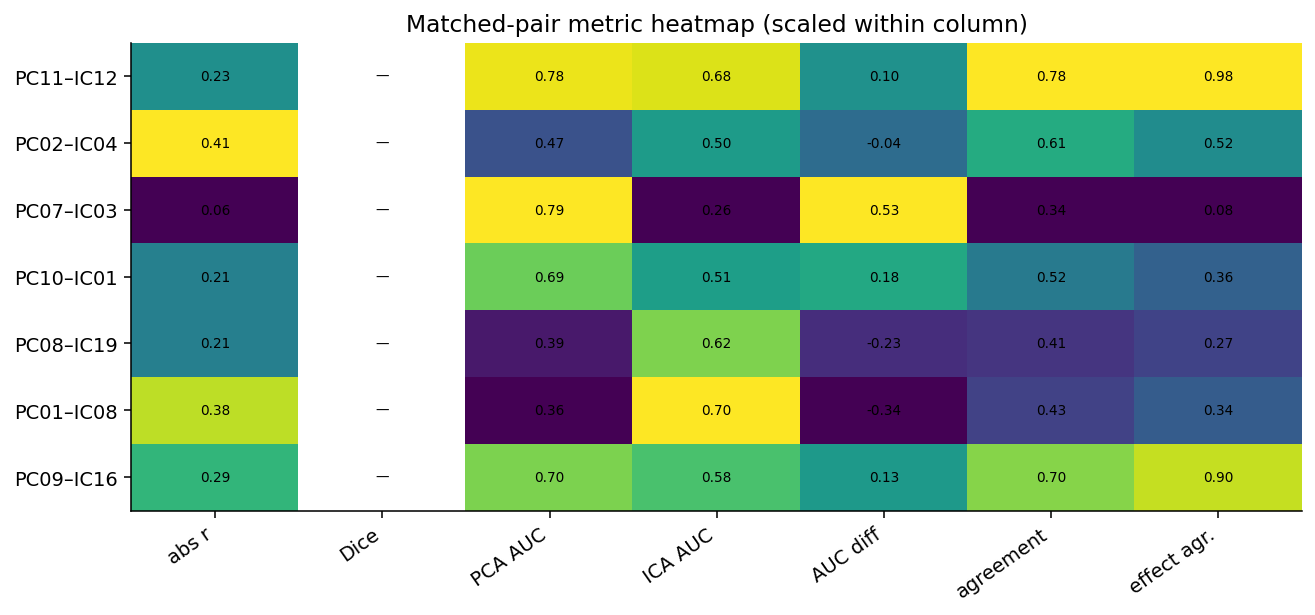

In [21]:
def minmax_scale_series(s):
    s = s.astype(float)
    if s.isna().all():
        return pd.Series(np.nan, index=s.index)
    mn, mx = s.min(skipna=True), s.max(skipna=True)
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)


def build_heatmap_matrix(df):
    data = df.copy()

    if (not data["delta_effect_profile_corr"].isna().all()) or (not data["ln_effect_profile_corr"].isna().all()):
        data["effect_agreement_summary"] = np.nanmean(
            np.vstack([
                data["delta_effect_profile_corr"].astype(float).values,
                data["ln_effect_profile_corr"].astype(float).values
            ]),
            axis=0
        )
    else:
        data["effect_agreement_summary"] = np.nan

    metric_cols = [
        "abs_spatial_r",
        "dice",
        "PCA_Ln_AUC",
        "ICA_Ln_AUC",
        "auc_diff",
        "overall_subject_agreement_score",
        "effect_agreement_summary",
    ]

    hm = data[["pair", "group"] + metric_cols].copy()
    hm["group_sort"] = hm["group"].map({
        "shared-signal": 0,
        "PCA-dominant": 1,
        "ICA-dominant": 2,
        "mixed/unclear": 3,
    }).fillna(9)
    hm = hm.sort_values(["group_sort", "auc_diff"], ascending=[True, False]).reset_index(drop=True)

    hm_scaled = hm.copy()
    for col in metric_cols:
        hm_scaled[col] = minmax_scale_series(hm_scaled[col])

    return hm, hm_scaled, metric_cols


def plot_metric_heatmap(df, outpath=None):
    hm_raw, hm_scaled, metric_cols = build_heatmap_matrix(df)

    fig, ax = plt.subplots(figsize=(9.5, max(4.5, 0.45 * len(hm_scaled))))
    im = ax.imshow(hm_scaled[metric_cols].values, aspect="auto")

    ax.set_xticks(np.arange(len(metric_cols)))
    ax.set_xticklabels(
        ["abs r", "Dice", "PCA AUC", "ICA AUC", "AUC diff", "agreement", "effect agr."],
        rotation=35, ha="right"
    )
    ax.set_yticks(np.arange(len(hm_scaled)))
    ax.set_yticklabels(hm_scaled["pair"])

    ax.set_title("Matched-pair metric heatmap (scaled within column)")

    for i in range(len(hm_scaled)):
        for j, col in enumerate(metric_cols):
            val = hm_raw.iloc[i][col]
            text = "—" if pd.isna(val) else f"{val:.2f}"
            ax.text(j, i, text, ha="center", va="center", fontsize=7)

    plt.tight_layout()
    if outpath is not None:
        plt.savefig(outpath, bbox_inches="tight")
    plt.show()

    return hm_raw, hm_scaled


heatmap_raw, heatmap_scaled = plot_metric_heatmap(
    pairs_df,
    outpath=OUTDIR / "figure3_pair_metric_heatmap.png",
)


## 7. Optional: export a clean summary table

This is useful for the paper, captions, or Overleaf table creation.


In [22]:
summary_cols = [
    "pca_component", "ica_component", "pair", "group",
    "abs_spatial_r", "dice",
    "PCA_Ln_AUC", "ICA_Ln_AUC", "auc_diff",
    "overall_subject_agreement_score",
    "delta_effect_profile_corr", "ln_effect_profile_corr",
    "mean_feature_subject_corr_ln",
]

summary_df = pairs_df[[c for c in summary_cols if c in pairs_df.columns]].copy()
summary_df = summary_df.sort_values(["group", "auc_diff"], ascending=[True, False]).reset_index(drop=True)
summary_df.to_csv(OUTDIR / "matched_pair_summary_for_figures.csv", index=False)
summary_df


,pca_component,ica_component,pair,group,abs_spatial_r,dice,PCA_Ln_AUC,ICA_Ln_AUC,auc_diff,overall_subject_agreement_score,delta_effect_profile_corr,ln_effect_profile_corr,mean_feature_subject_corr_ln
0,PC08,IC19,PC08–IC19,ICA-dominant,0.210,NaN,0.388,0.618,-0.230,0.410,0.310,0.220,0.18
1,PC01,IC08,PC01–IC08,ICA-dominant,0.376,NaN,0.358,0.703,-0.345,0.430,0.280,0.410,0.26
2,PC07,IC03,PC07–IC03,PCA-dominant,0.058,NaN,0.788,0.261,0.527,0.344,0.120,0.050,0.10
3,PC10,IC01,PC10–IC01,PCA-dominant,0.212,NaN,0.691,0.509,0.182,0.520,0.420,0.300,0.22
4,PC09,IC16,PC09–IC16,mixed/unclear,0.291,NaN,0.703,0.576,0.127,0.697,0.994,0.803,0.42
5,PC11,IC12,PC11–IC12,shared-signal,0.234,NaN,0.776,0.679,0.097,0.776,0.971,0.981,0.48
6,PC02,IC04,PC02–IC04,shared-signal,0.411,NaN,0.467,0.503,-0.036,0.610,0.536,0.500,0.35


## 8. Suggested interpretation template

Use these figures to support the following story:

- **Figure 1 (scatter):**  
  spatial similarity alone does not determine predictive similarity.  
  Some pairs with only modest spatial overlap still have small AUC differences, while others are clearly PCA-dominant or ICA-dominant.

- **Figure 2 (summary panel):**  
  matched pairs can be grouped into three intuitive classes: shared-signal, PCA-dominant, and ICA-dominant.

- **Figure 3 (heatmap):**  
  the relationship between PCA and ICA is multi-dimensional: spatial overlap, predictive asymmetry, subject-level agreement, and effect-profile agreement do not always move together.

That supports the conclusion that **PCA and ICA are complementary rather than interchangeable**.
